In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emd
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from sklearn.preprocessing import MinMaxScaler
from tslearn.preprocessing import TimeSeriesResampler

numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


In [2]:
P8_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P8.csv', 
                 sep = ';', na_values = 'n.a.')
P10_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P10.csv', 
                  sep = ';', na_values = 'n.a.')

In [3]:
P8_df = P8_df.fillna(method = 'ffill')
P10_df = P10_df.fillna(method = 'ffill')

# Functions

In [4]:
def transformer(tple, X):
    '''
    INPUTS
    ------
        - tple : list
            List of tuples of the transformation vector to apply.
        - X : 1Darray
            Array to reshape.
            
    OUTPUT
    ------
        - transform_list : list
            Vector of the X2 positions to apply to X1 data.
    '''
    import operator
    from itertools import groupby
    
    transform_list = []
    for k, g in groupby(tple, operator.itemgetter(0)):
        x = list(g)
        bst_val = []
        for i in x:
            val = i[1]
            pval = X[val]
            bst_val.append(pval)
        
        pos = np.argmin(abs(np.array(bst_val) - np.mean(bst_val)))
        bst_pos = x[pos][1]
        transform_list.append(bst_pos)

    return transform_list

In [5]:
def peaks_to_line(X, peaks):
    new_y = [0]*len(X)
    
    for i in peaks :
        new_y[i] = y[i]
        
    return np.array(new_y)

## Scaling 

On met chaque variable entre 0 et 1 afin d'améliorer les analyses

In [6]:
scaler = MinMaxScaler()

P8_scaled = pd.DataFrame(scaler.fit_transform(P8_df),
                     index = P8_df.index,
                     columns = P8_df.columns)

P10_scaled = pd.DataFrame(scaler.fit_transform(P10_df),
                      index = P10_df.index,
                      columns = P10_df.columns)

In [7]:
P8_scaled = np.array(P8_scaled['msa'])
P10_scaled = np.array(P10_scaled['msa'])

# Clustering

In [8]:
from scipy.signal import savgol_filter, find_peaks

In [9]:
y = savgol_filter(P8_scaled, 3, 2)

In [10]:
peaks1, _ = find_peaks(y, prominence = 0.05)

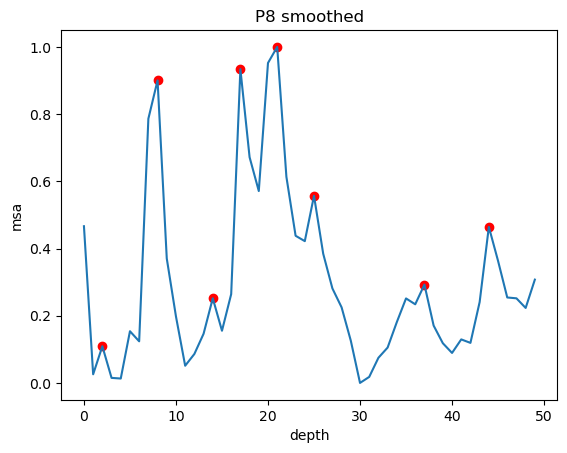

In [16]:
plt.plot(y)
plt.scatter(peaks1, y[peaks1], color = 'red')
plt.title('P8 smoothed')
plt.ylabel('msa')
plt.xlabel('depth')
plt.show()

In [12]:
y2 = savgol_filter(P10_scaled, 3, 2)

In [13]:
peaks2, _ = find_peaks(y2, prominence = 0.05)

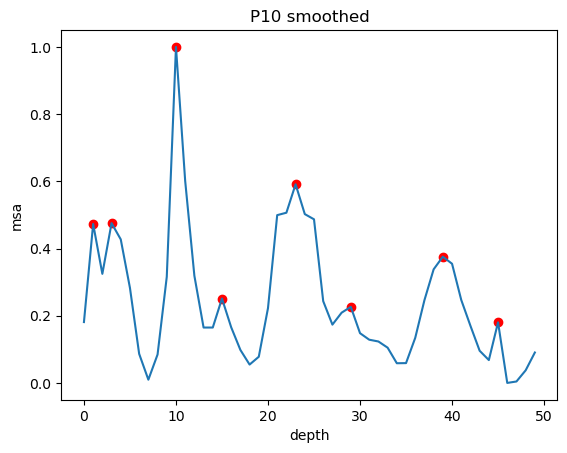

In [15]:
plt.plot(y2)
plt.scatter(peaks2, y2[peaks2], color = 'red')
plt.title('P10 smoothed')
plt.ylabel('msa')
plt.xlabel('depth')
plt.show()

In [17]:
new_y1 = np.array(peaks_to_line(y, peaks1))
new_y2 = np.array(peaks_to_line(y2, peaks2))

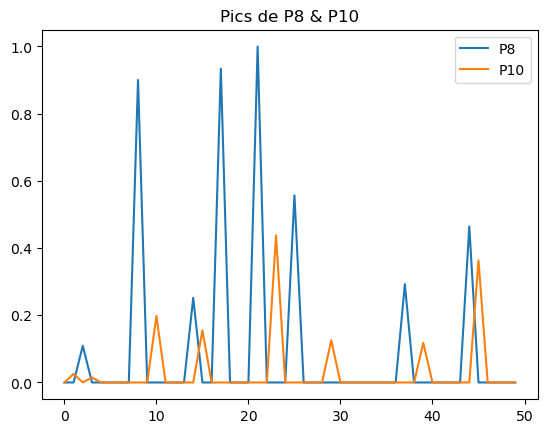

In [18]:
plt.plot(new_y1, label = 'P8')
plt.plot(new_y2, label = 'P10')
plt.title('Pics de P8 & P10')
plt.legend()
plt.show()

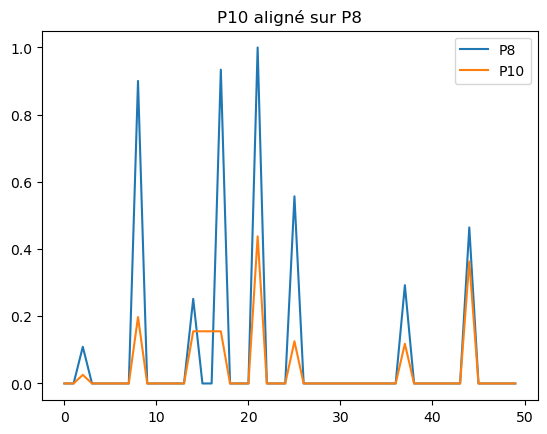

In [19]:
tuple_transform = dtw.warping_path(new_y1, new_y2)
list_transform = transformer(tuple_transform, P10_scaled)

plt.plot(new_y1, label = 'P8')
plt.plot(new_y2[list_transform], label = 'P10')
plt.legend()
plt.title('P10 aligné sur P8')
plt.show()

In [20]:
X = new_y2[list_transform]

In [21]:
end = np.array([0] * len(X))

count = 1
max_pos = np.where(X != 0)[0]
dic_transform = dict(tuple_transform)

for i in range(len(max_pos)) :
    # Label 1 : données transformées
    # Label 2 : données initiales
    peak1 = max_pos[i]
    peak2 = dic_transform[peak1]
    end[peak1] = P10_df.loc[peak2, 'msa']

    if count == 1 :
        min_pos2 = np.argmin(P10_df.loc[:peak2, 'msa'])
        min_val2 = np.min(P10_df.loc[:peak2, 'msa'])
        min_pos1 = np.argmin(P8_df.loc[:peak1, 'msa'])
        end[min_pos1] = min_val2

        
    elif count < len(max_pos) :
        # On se trouve entre 2 pics, et on cherche le minimum entre :
        fst_peak1 = max_pos[i-1]
        fst_peak2 = dic_transform[fst_peak1]
        min_pos2 = np.argmin(P10_df.loc[fst_peak2:peak2, 'msa']) + fst_peak2
        min_val2 = np.min(P10_df.loc[fst_peak2:peak2, 'msa'])
        min_pos1 = np.argmin(P8_df.loc[fst_peak1:peak1, 'msa']) + fst_peak1

        end[min_pos1] = min_val2

        if (min_pos1 > fst_peak1 + 1) & (min_pos2 > fst_peak2) :
            ar2 = TimeSeriesResampler(sz = min_pos1-fst_peak1-1).fit_transform(
                np.array(P10_df.loc[fst_peak2:min_pos2, 'msa'])).flatten()
            end[fst_peak1+1:min_pos1] = ar2
            
        if (peak1 > min_pos1 +1) & (peak2 > min_pos2) :
            ar2 = TimeSeriesResampler(sz = peak1-min_pos1-1).fit_transform(
                np.array(P10_df.loc[min_pos2:peak2, 'msa'])).flatten()
            end[min_pos1+1:peak1] = ar2            

    else :
        min_pos2 = np.argmin(P10_df.loc[peak2:, 'msa']) + peak2
        min_val2 = np.min(P10_df.loc[peak2:, 'msa'])
        min_pos1 = np.argmin(P8_df.loc[peak1:, 'msa']) + peak1
        lst_pos2 = P10_df.index[-1]
        lst_pos1 = P8_df.index[-1]
        end[min_pos1] = min_val2
        
        if (min_pos1 > peak1 +1) & (min_pos2 > peak2) :
            ar2 = TimeSeriesResampler(sz = min_pos1-peak1-1).fit_transform(
                np.array(P10_df.loc[peak2:min_pos2, 'msa'])).flatten()
            end[peak1+1:min_pos1] = ar2  
            
        if (lst_pos1 > min_pos1 + 1) & (lst_pos2 > min_pos2) :
            ar2 = TimeSeriesResampler(sz = lst_pos1-min_pos1-1).fit_transform(
                np.array(P10_df.loc[min_pos2:, 'msa'])).flatten()
            end[min_pos1+1:] = ar2              
        else :
            end = end[:min_pos1+1]


    count += 1

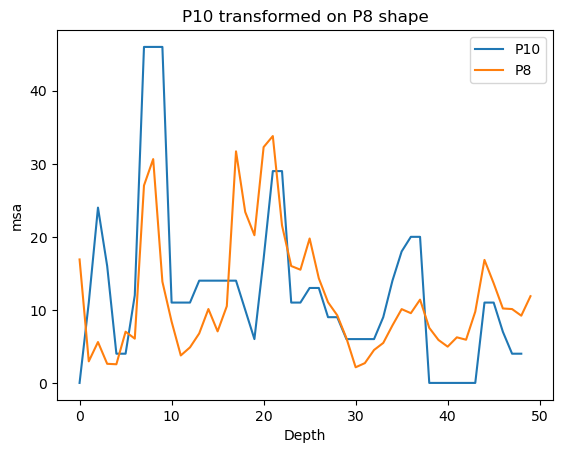

In [116]:
plt.plot(end, label = 'P10')
plt.plot(P8_df['msa'], label = 'P8')
plt.title('P10 transformed on P8 shape')
plt.legend()
plt.xlabel('Depth')
plt.ylabel('msa')
plt.show()

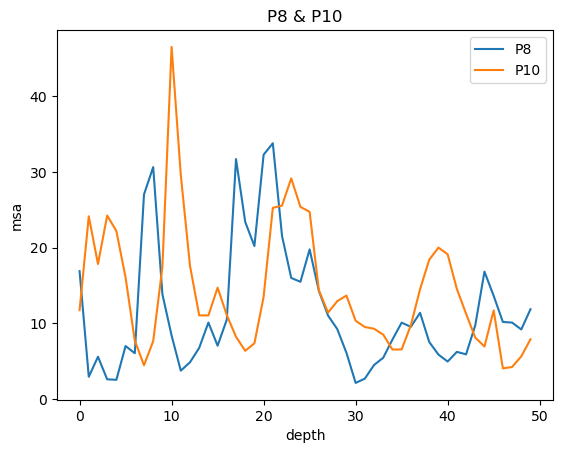

In [22]:
plt.plot(P8_df['msa'], label = 'P8')
plt.plot(P10_df['msa'], label = 'P10')
plt.legend()
plt.title('P8 & P10')
plt.ylabel('msa')
plt.xlabel('depth')
plt.show()

# EMD method

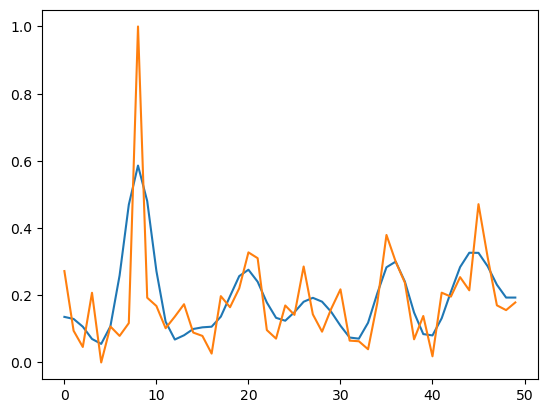

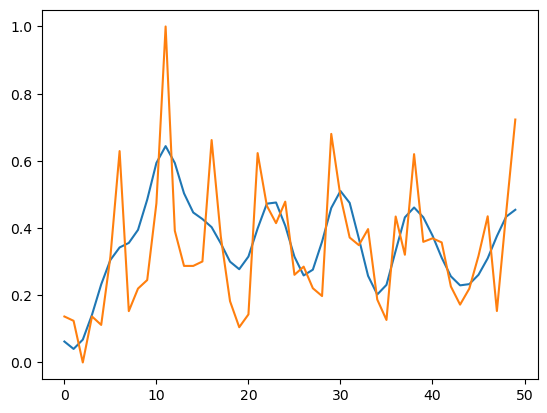

In [22]:
for i in [P8, P10] :
    imf = emd.sift.mask_sift(i, max_imfs = 3)
    plt.plot(i - imf[:, 0])
    plt.plot(i)
    plt.show()

In [74]:
#emd.plotting.plot_imfs(imf)